# Employee Attrition Classification (Logistic Regression vs. Random Forest)

**Aim:** Build and compare models that classify employee attrition as **Yes** or **No**.

**Tools used:**
1. NumPy, Pandas
2. Matplotlib, Seaborn
3. Scikit-learn


In [47]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report


**Loading the dataset and performing basic exploration:**

**Dataset link:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [48]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')


In [49]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [50]:
df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [51]:
df.describe()

# Looking at the difference between (min and 25%) and (max and 75%) values:
# there's no extreme gap for most columns, a mild sign of an absence of major outliers.


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [53]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [54]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


The Yes/No classes are imbalanced (roughly 84% No / 16% Yes), so accuracy alone would be
misleading - a model predicting "No" for everyone would still score ~84% accuracy while
catching zero actual attrition cases. We use (class_weight='balanced') on both models below
and look at precision/recall on the "Yes" class, not just accuracy.


In [55]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [56]:
# Checking for null values
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**EDA:** using a correlation heatmap to check relationships between the numeric features.

**Dropping unecessary columns:** EmployeeCount, StandardHours, and Over18 are constant
for every row (no information), and EmployeeNumber is just a row ID. All four are dropped
**before** we build 'x', so the split-off feature matrix never contains them.


In [57]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])


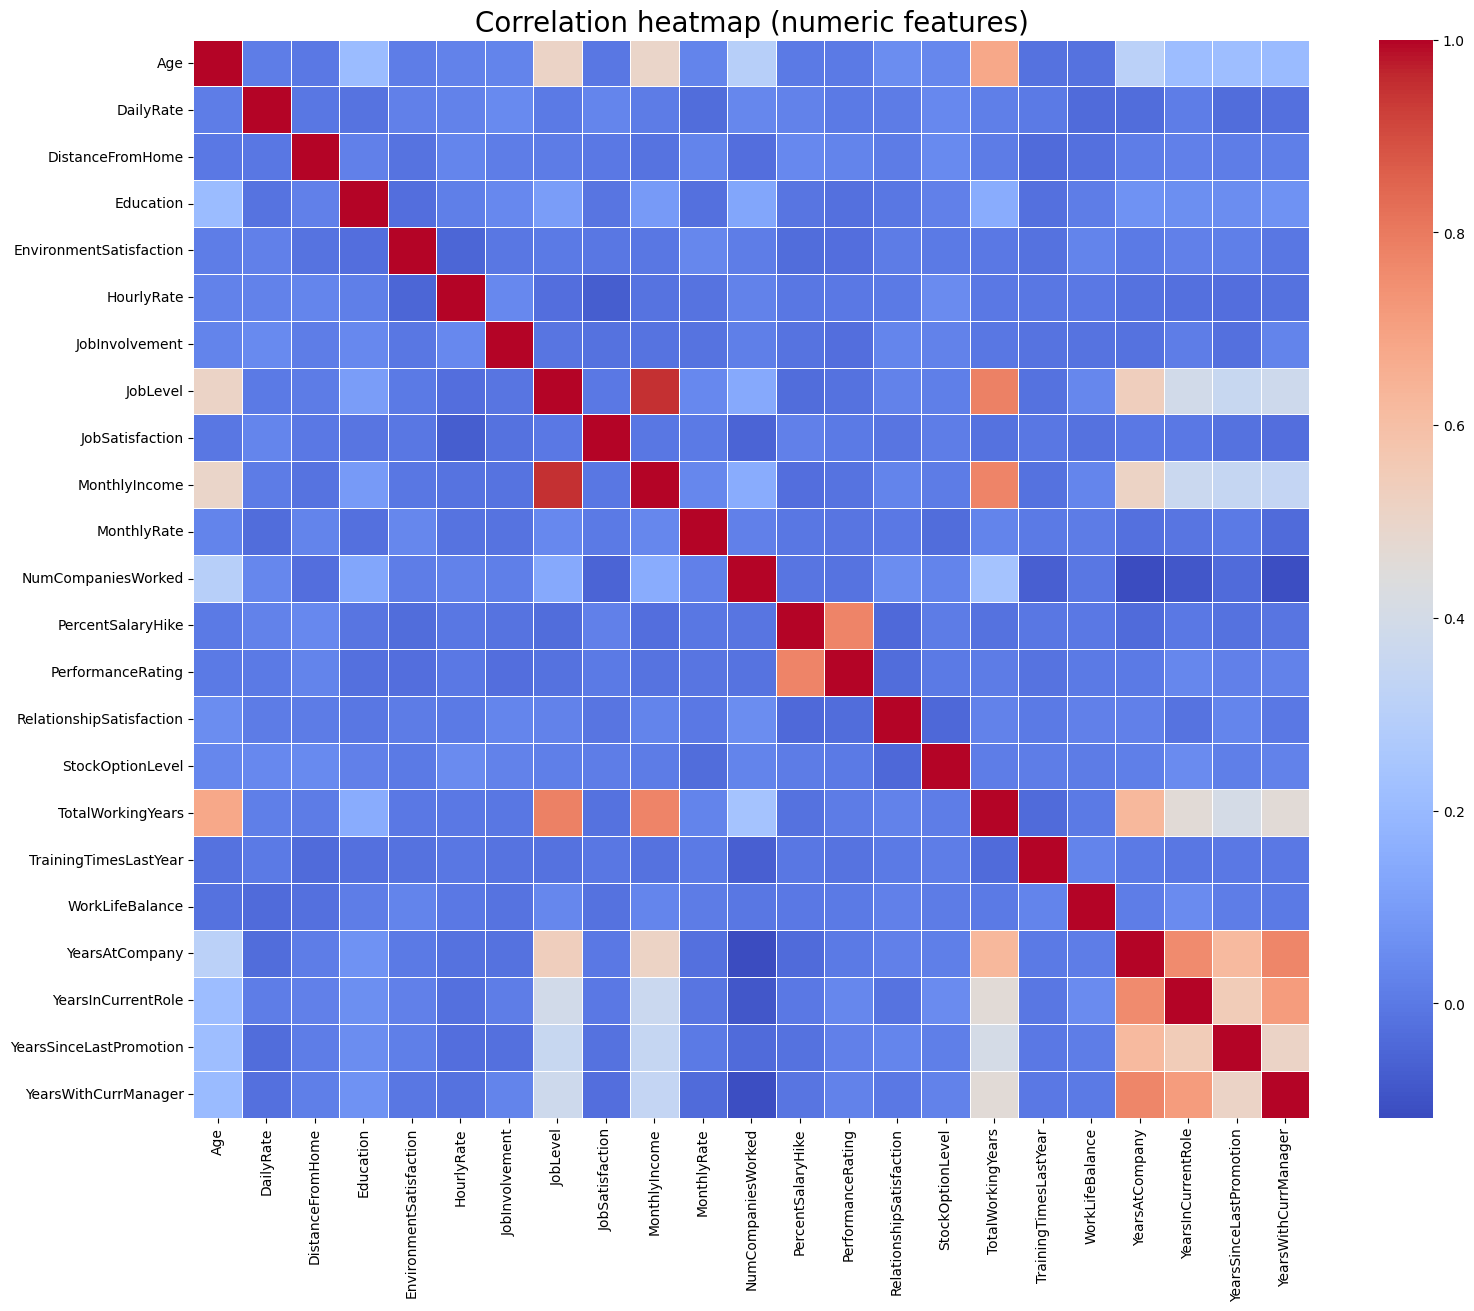

In [58]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(18, 14))
sns.heatmap(data=numeric_df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap (numeric features)', fontsize=20)
plt.show()


**Target column = Attrition**

In [59]:
# Splitting the target column from the features.
# (Columns dropped above are already gone from df, so x never contains them.)
x = df.drop(columns=['Attrition'])
y = df['Attrition'].map({'Yes': 1, 'No': 0})  # convert object dtype Yes/No to 1/0
y.unique()


array([1, 0])

**Encoding categorical features:** using one-hot encoding (pd.get_dummies) rather than
label-encoding them as arbitrary integers. Label-encoding a column like Department would
assign values like Sales=0, R&D=1, HR=2, which implies a false ordinal relationship
("R&D is between Sales and HR") that doesn't exist and can distort what the model learns -
especially for Logistic Regression.


In [60]:
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
x.shape


Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


(1470, 44)

**Train/test split.** With only ~237 employees who left out of ~1470 total, an unstratified
split could easily land a different attrition rate in train vs. test - (stratify=y) keeps the
ratio consistent in both.


In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42, stratify=y)

print(f'The shape of x_train is: {x_train.shape}')
print(f'The shape of x_test is: {x_test.shape}')
print(f'The shape of y_train is: {y_train.shape}')
print(f'The shape of y_test is: {y_test.shape}')


The shape of x_train is: (1176, 44)
The shape of x_test is: (294, 44)
The shape of y_train is: (1176,)
The shape of y_test is: (294,)


In [62]:
sc = StandardScaler()
# We use standard scaler to scale the data so no feature overshadows importance of other features due to large values

In [63]:
xtrain_scaled = sc.fit_transform(x_train)
xtest_scaled = sc.transform(x_test)

**Classification using Logistic Regression**

In [64]:
log_model = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
log_model.fit(xtrain_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [65]:
log_pred = log_model.predict(xtest_scaled)
log_proba = log_model.predict_proba(xtest_scaled)[:, 1]  # probabilities give a more standard ROC-AUC than hard 0/1 predictions


In [66]:
roc_logr = roc_auc_score(y_test, log_proba)
roc_logr

np.float64(0.7982599707123783)

In [67]:
cm_log = confusion_matrix(y_test, log_pred)

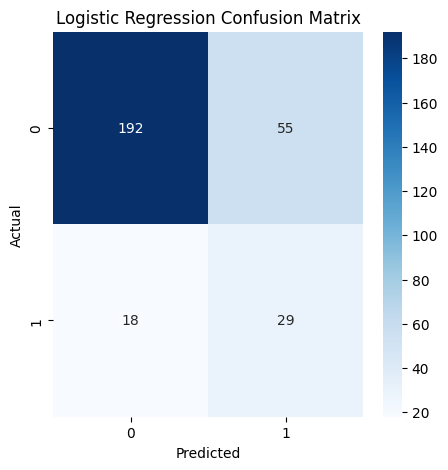

In [68]:
plt.figure(figsize=(5, 5))
sns.heatmap(cm_log, annot=True, cmap='Blues', fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [69]:
report_logrg = classification_report(y_test, log_pred)
print('Classification Report (Logistic Regression):\n', report_logrg)


Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



**Classification using Random Forest**

In [70]:
random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state= 42)

In [71]:
random_forest.fit(xtrain_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [72]:
rf_pred = random_forest.predict(xtest_scaled)
rf_proba = random_forest.predict_proba(xtest_scaled)[:, 1]


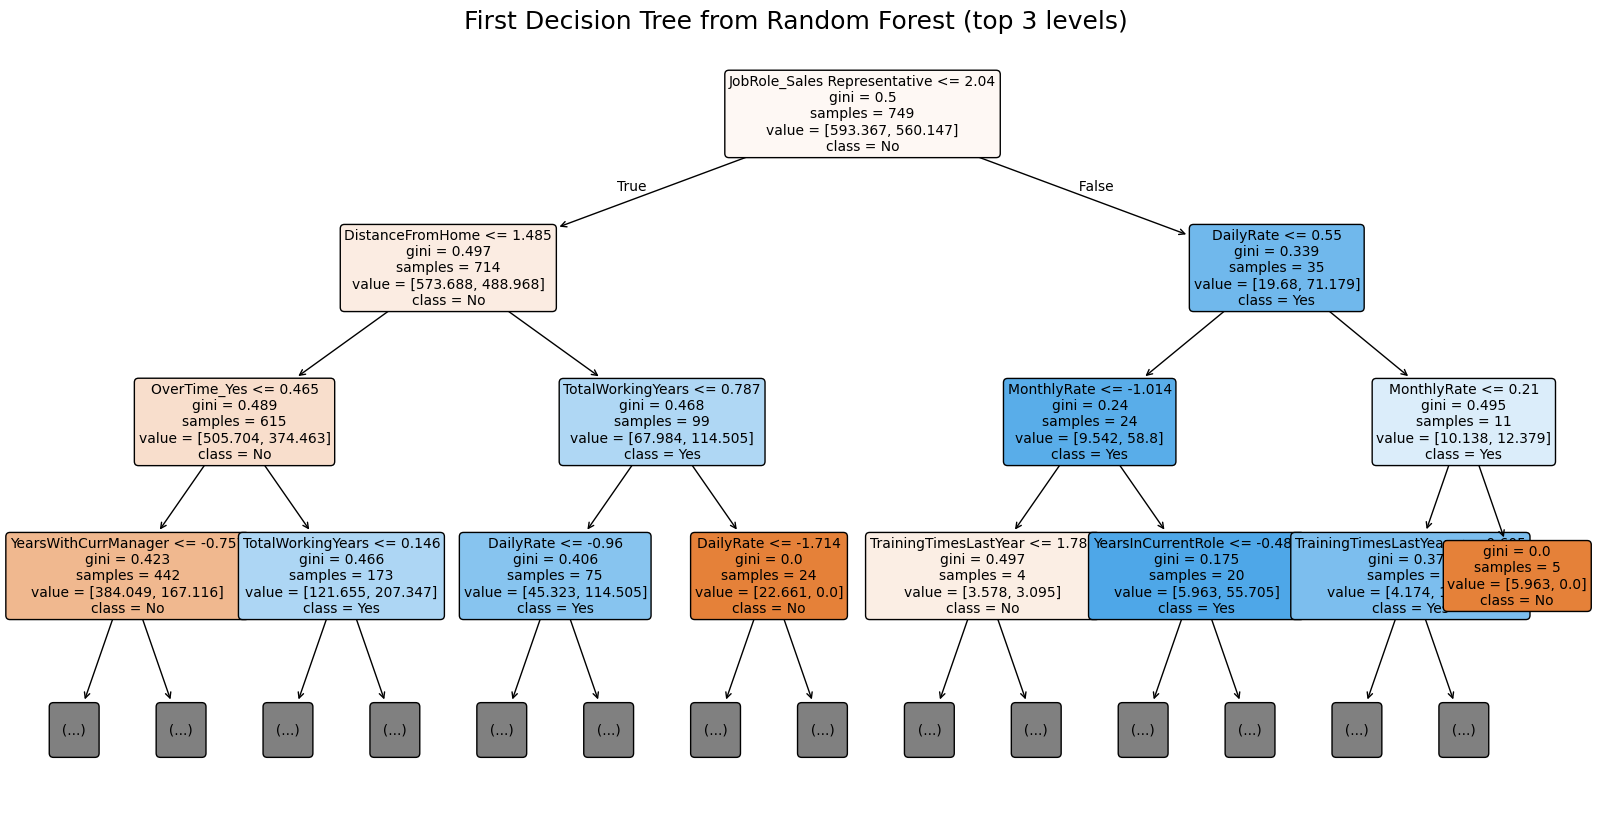

In [73]:
# Visualizing one tree from the forest, capped at depth 3 for a readable plot
# (the forest's own trees go to max_depth=10 - this is just for display).
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(random_forest.estimators_[0], filled=True, feature_names=x.columns,class_names=['No', 'Yes'], rounded=True, fontsize=10, max_depth=3)
plt.title('First Decision Tree from Random Forest (top 3 levels)', fontsize=18)
plt.show()


In [74]:
roc_rf = roc_auc_score(y_test, rf_proba)
print(roc_rf)

0.7385649065380309


In [75]:
report_rf = classification_report(y_test, rf_pred)
print('Classification Report (Random forest):\n', report_rf)


Classification Report (Random forest):
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [76]:
cm_rf = confusion_matrix(y_test, rf_pred)

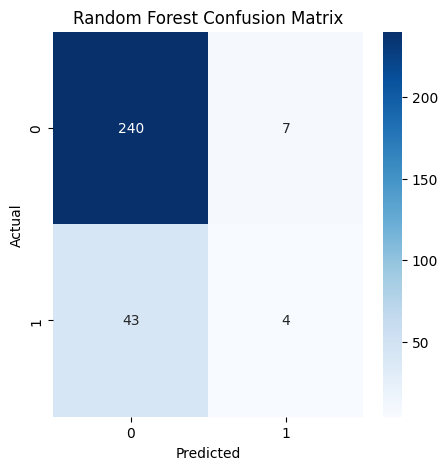

In [77]:
plt.figure(figsize=(5, 5))
sns.heatmap(cm_rf, annot=True, cmap='Blues', fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [78]:
importances = pd.Series(random_forest.feature_importances_, index=x.columns).sort_values(ascending=False)

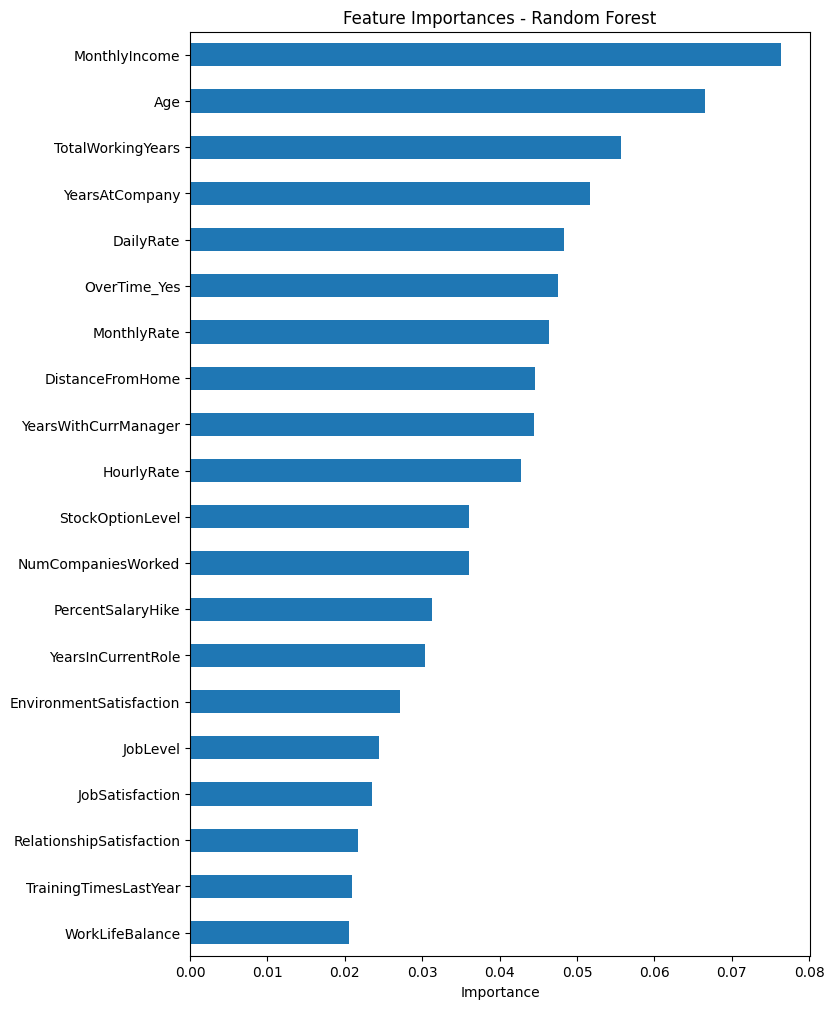

In [79]:
plt.figure(figsize=(8, 12))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()
# With the help of this plot we can understand which features were most important to the Random Forest's decisions.


**Model comparison**

In [80]:
#We Create a dictionary of ROC-AUC scores with model names
model_performance = {
    'RandomForest': roc_rf,
    'LogisticRegression': roc_logr}


In [81]:
# Create a DataFrame from the dictionary, explicitly naming the column 'roc_auc'.
# orient='index' sets the model names from the dictionary as the DataFrame's index.
comparison_df = pd.DataFrame.from_dict(model_performance, orient='index', columns=['roc_auc'])

In [82]:
# Sort by 'roc_auc' descending
comparison_df = comparison_df.sort_values('roc_auc', ascending=False)
comparison_df


,roc_auc
LogisticRegression,0.798260
RandomForest,0.738565


In [83]:
# Choosing the best model using ROC-AUC score
best_model_name = comparison_df.index[0]
print(f"Best model by ROC-AUC: {best_model_name}")


Best model by ROC-AUC: LogisticRegression
